## Customer Churn Prediction

## 1. Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Generate Realistic Synthetic Dataset

In [2]:
df = pd.read_csv("Customer_Churn.csv")


In [3]:
print(f"Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean()*100:.2f}%")

Churn distribution:
Churn
0    1022
1     978
Name: count, dtype: int64
Churn rate: 48.90%


## 3. Exploratory Data Analysis

In [4]:
# Display first few rows
df.head()

,Unnamed: 0,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,ContractType,PaymentMethod,InternetService,TechSupport,OnlineSecurity,CustomerServiceCalls,DataUsageGB,Churn
0,0,CUST0000,49,29,103.58,2935.57,One year,Electronic check,DSL,No,No,2,87.47,0
1,1,CUST0001,65,36,97.04,3513.25,Month-to-month,Bank transfer,Fiber optic,No,No,2,79.16,0
2,2,CUST0002,70,9,43.54,458.30,One year,Credit card,Fiber optic,Yes,Yes,1,120.09,1
3,3,CUST0003,61,23,24.47,576.58,One year,Electronic check,No,No,No,1,44.85,0
4,4,CUST0004,72,3,83.53,294.89,One year,Mailed check,Fiber optic,No,Yes,4,42.60,0


In [5]:
# Dataset info
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            2000 non-null   int64  
 1   CustomerID            2000 non-null   str    
 2   Age                   2000 non-null   int64  
 3   Tenure                2000 non-null   int64  
 4   MonthlyCharges        2000 non-null   float64
 5   TotalCharges          2000 non-null   float64
 6   ContractType          2000 non-null   str    
 7   PaymentMethod         2000 non-null   str    
 8   InternetService       2000 non-null   str    
 9   TechSupport           2000 non-null   str    
 10  OnlineSecurity        2000 non-null   str    
 11  CustomerServiceCalls  2000 non-null   int64  
 12  DataUsageGB           2000 non-null   float64
 13  Churn                 2000 non-null   int64  
dtypes: float64(3), int64(5), str(6)
memory usage: 304.5 KB


In [6]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges,CustomerServiceCalls,DataUsageGB,Churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,46.759500,35.334000,84.290085,2983.535570,2.026500,101.028755,0.489000
std,577.494589,16.740035,20.977022,37.110699,2360.989382,1.424013,45.057089,0.500004
min,0.000000,18.000000,1.000000,20.050000,28.250000,0.000000,11.600000,0.000000
25%,499.750000,33.000000,17.000000,53.472500,1075.245000,1.000000,68.190000,0.000000
50%,999.500000,47.000000,35.000000,83.485000,2385.705000,2.000000,93.905000,0.000000
75%,1499.250000,61.000000,53.000000,115.500000,4376.852500,3.000000,126.732500,1.000000
max,1999.000000,75.000000,72.000000,149.990000,10527.580000,9.000000,308.710000,1.000000


In [7]:
# Check for missing values
print("Missing Values:")
df.isnull().sum()

Missing Values:


Unnamed: 0              0
CustomerID              0
Age                     0
Tenure                  0
MonthlyCharges          0
TotalCharges            0
ContractType            0
PaymentMethod           0
InternetService         0
TechSupport             0
OnlineSecurity          0
CustomerServiceCalls    0
DataUsageGB             0
Churn                   0
dtype: int64

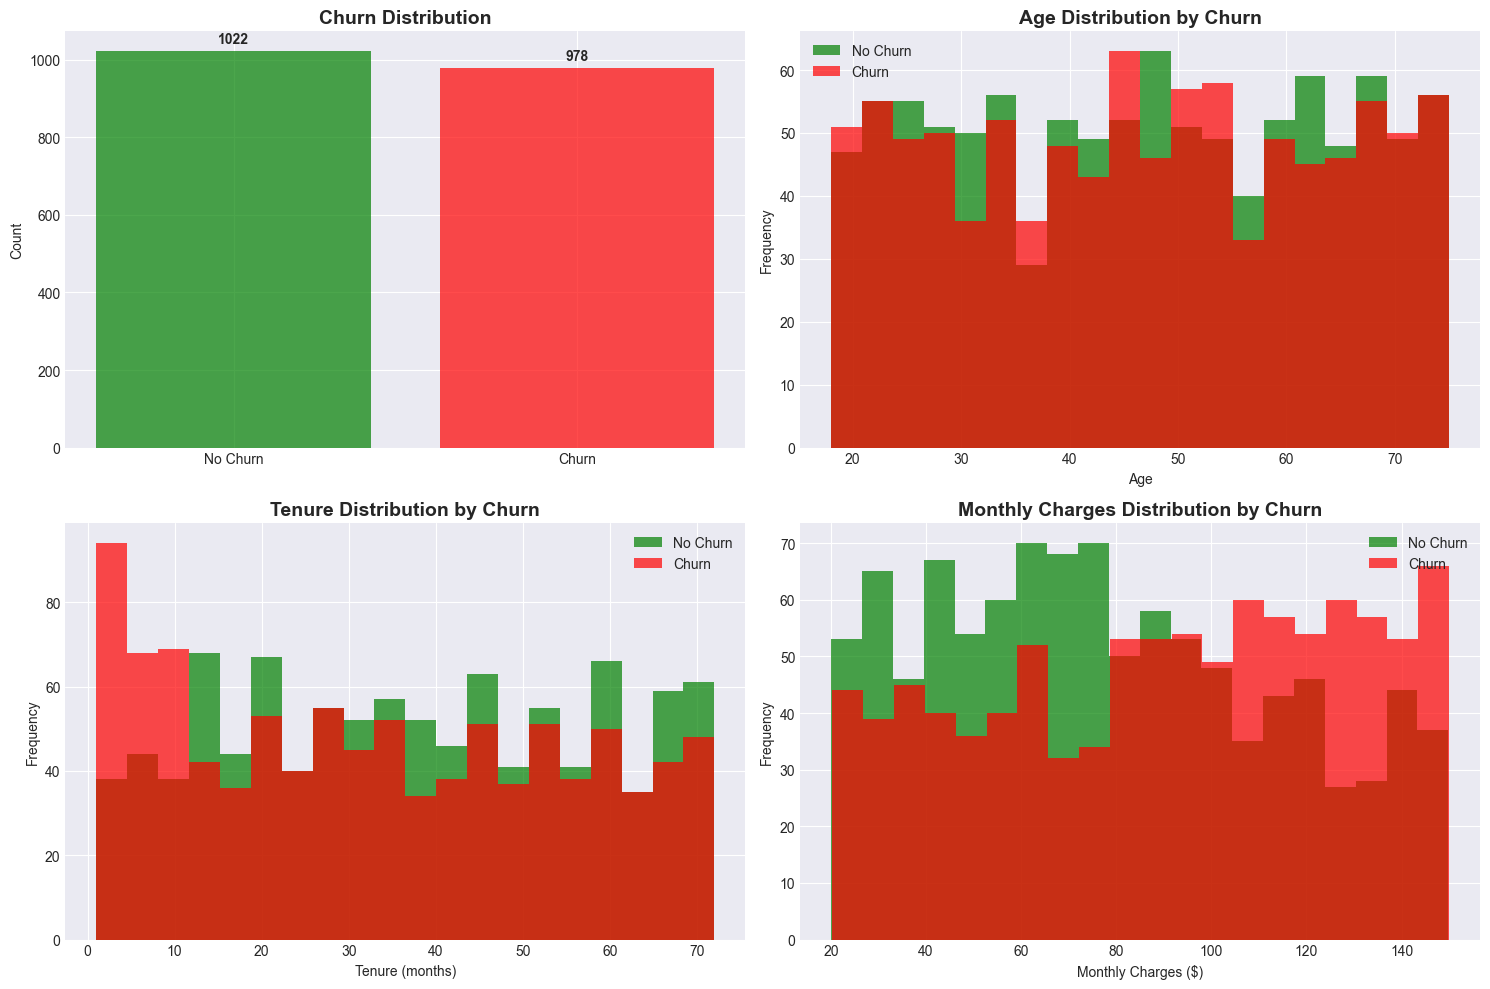

In [8]:
# Visualize churn distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].bar(['No Churn', 'Churn'], churn_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0, 0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Age distribution by churn
df[df['Churn']==0]['Age'].hist(ax=axes[0, 1], bins=20, alpha=0.7, label='No Churn', color='green')
df[df['Churn']==1]['Age'].hist(ax=axes[0, 1], bins=20, alpha=0.7, label='Churn', color='red')
axes[0, 1].set_title('Age Distribution by Churn', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Tenure distribution by churn
df[df['Churn']==0]['Tenure'].hist(ax=axes[1, 0], bins=20, alpha=0.7, label='No Churn', color='green')
df[df['Churn']==1]['Tenure'].hist(ax=axes[1, 0], bins=20, alpha=0.7, label='Churn', color='red')
axes[1, 0].set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Monthly charges distribution by churn
df[df['Churn']==0]['MonthlyCharges'].hist(ax=axes[1, 1], bins=20, alpha=0.7, label='No Churn', color='green')
df[df['Churn']==1]['MonthlyCharges'].hist(ax=axes[1, 1], bins=20, alpha=0.7, label='Churn', color='red')
axes[1, 1].set_title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Monthly Charges ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

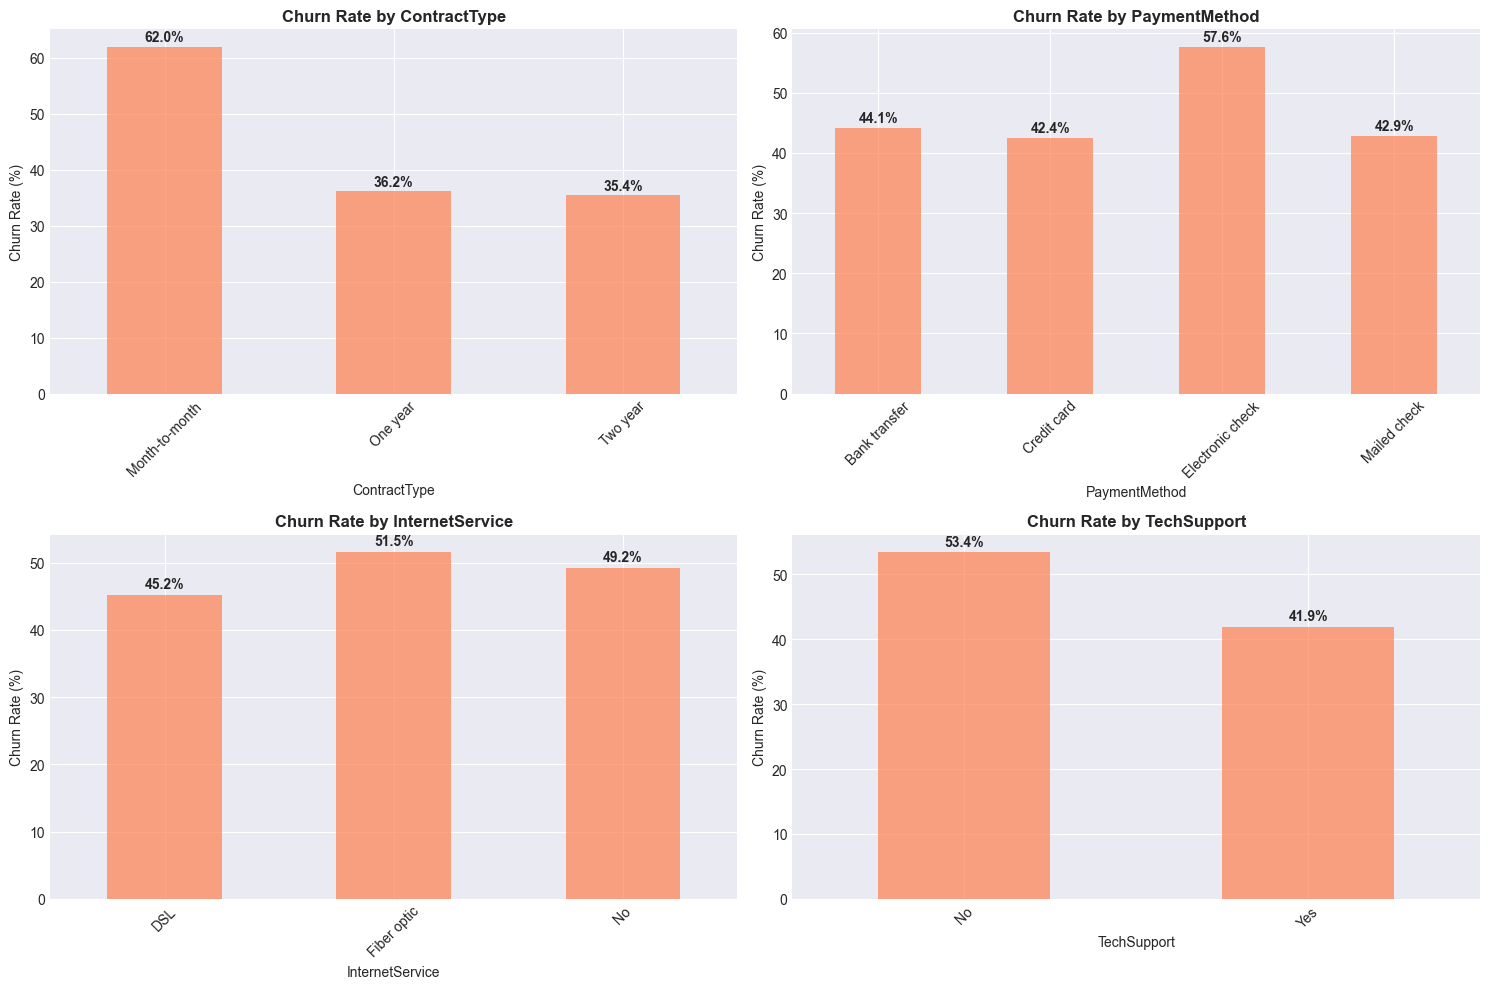

In [9]:
# Churn rate by categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

categorical_features = ['ContractType', 'PaymentMethod', 'InternetService', 'TechSupport']

for idx, feature in enumerate(categorical_features):
    row = idx // 2
    col = idx % 2
    
    churn_rate = df.groupby(feature)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[row, col], color='coral', alpha=0.7)
    axes[row, col].set_title(f'Churn Rate by {feature}', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Churn Rate (%)')
    axes[row, col].set_xlabel(feature)
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(churn_rate.values):
        axes[row, col].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

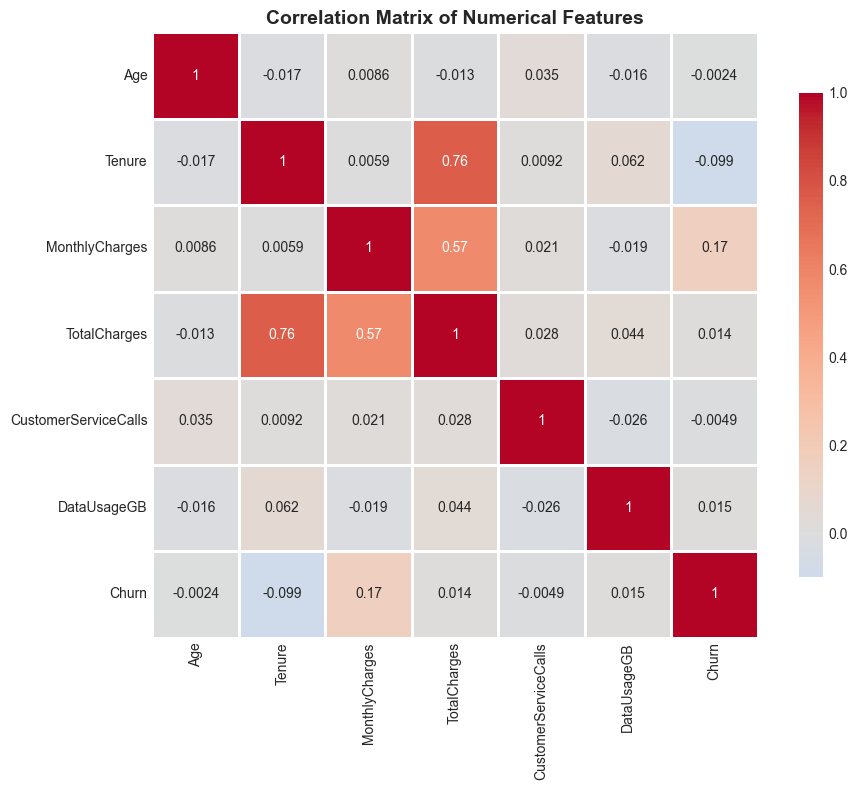

In [10]:
# Correlation heatmap for numerical features
numerical_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerServiceCalls', 'DataUsageGB', 'Churn']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [11]:
# Create a copy for preprocessing
df_processed = df.copy()

In [12]:
df.columns

Index(['Unnamed: 0', 'CustomerID', 'Age', 'Tenure', 'MonthlyCharges',
       'TotalCharges', 'ContractType', 'PaymentMethod', 'InternetService',
       'TechSupport', 'OnlineSecurity', 'CustomerServiceCalls', 'DataUsageGB',
       'Churn'],
      dtype='str')

In [13]:
# Drop CustomerID as it's not useful for prediction
df_processed = df_processed.drop(['CustomerID','Unnamed: 0'], axis=1)

In [14]:
# Encode categorical variables
categorical_columns = ['ContractType', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

In [15]:
 # One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df_processed, columns=categorical_columns, drop_first=True)

In [16]:
print("Shape after encoding:", df_encoded.shape)
print("Column names after encoding:")
print(df_encoded.columns.tolist())

Shape after encoding: (2000, 16)
Column names after encoding:
['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerServiceCalls', 'DataUsageGB', 'Churn', 'ContractType_One year', 'ContractType_Two year', 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No', 'TechSupport_Yes', 'OnlineSecurity_Yes']


In [17]:
# Separate features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [18]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

Features shape: (2000, 15)
Target shape: (2000,)
Feature columns: ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'CustomerServiceCalls', 'DataUsageGB', 'ContractType_One year', 'ContractType_Two year', 'PaymentMethod_Credit card', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No', 'TechSupport_Yes', 'OnlineSecurity_Yes']


In [19]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set churn rate: {y_train.mean()*100:.2f}%")
print(f"Testing set churn rate: {y_test.mean()*100:.2f}%")

Training set size: 1600 samples
Testing set size: 400 samples

Training set churn rate: 48.88%
Testing set churn rate: 49.00%


In [20]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model Training - Logistic Regression

In [21]:
# Train baseline Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
# Make predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Get prediction probabilities
y_train_pred_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

## 6. Model Evaluation

In [23]:
# Calculate evaluation metrics
def evaluate_model(y_true, y_pred, y_pred_proba, dataset_name=''):
    """
    Calculate and display comprehensive evaluation metrics
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"Evaluation Metrics for {dataset_name}")
    print()
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

In [24]:
# Evaluate on training set
train_metrics = evaluate_model(y_train, y_train_pred, y_train_pred_proba, 'Training Set')

Evaluation Metrics for Training Set

Accuracy:  0.6650 (66.50%)
Precision: 0.6610 (66.10%)
Recall:    0.6458 (64.58%)
F1-Score:  0.6533 (65.33%)
ROC-AUC:   0.7289 (72.89%)


In [25]:
# Evaluate on testing set
test_metrics = evaluate_model(y_test, y_test_pred, y_test_pred_proba, 'Testing Set')

Evaluation Metrics for Testing Set

Accuracy:  0.6400 (64.00%)
Precision: 0.6300 (63.00%)
Recall:    0.6429 (64.29%)
F1-Score:  0.6364 (63.64%)
ROC-AUC:   0.6835 (68.35%)


In [26]:
# Classification Report
print("Classification Report for Testing Set:")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

Classification Report for Testing Set:
              precision    recall  f1-score   support

    No Churn       0.65      0.64      0.64       204
       Churn       0.63      0.64      0.64       196

    accuracy                           0.64       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.64      0.64      0.64       400



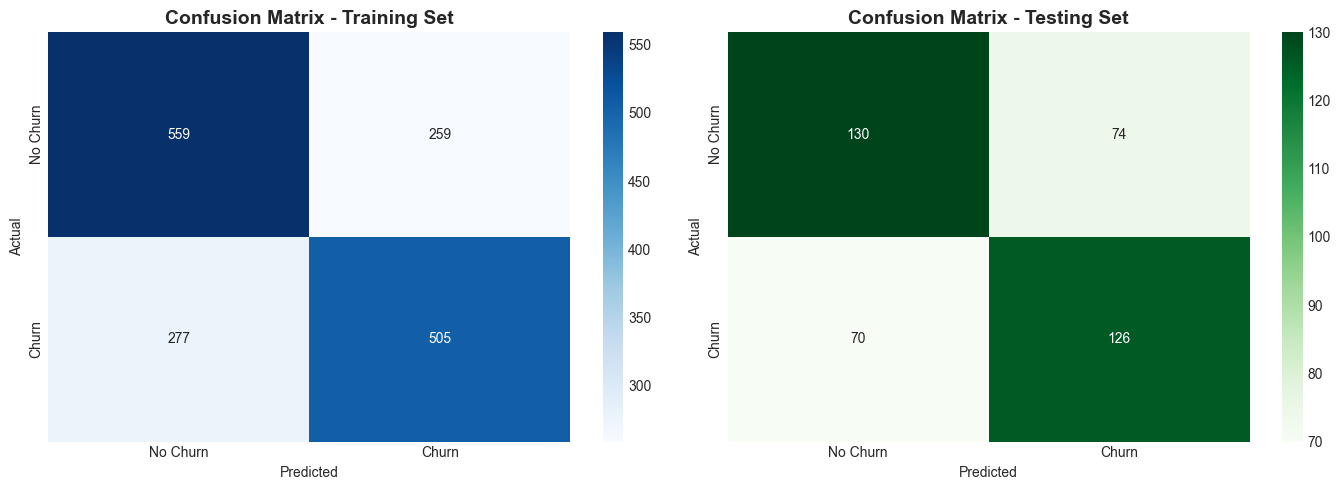

In [27]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix - Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Testing set confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix - Testing Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

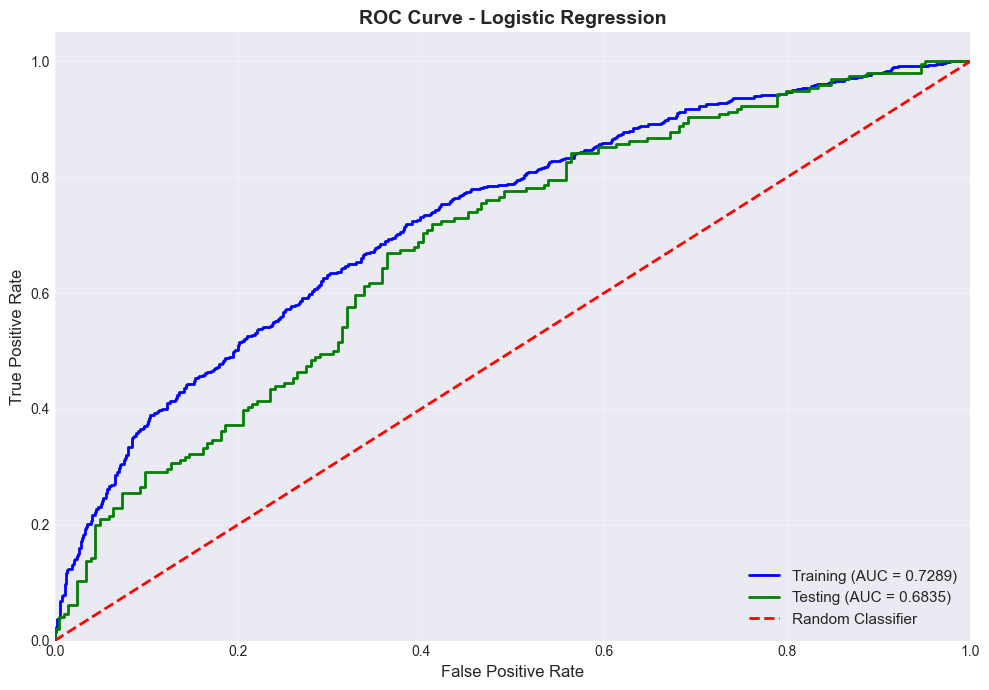

In [28]:
# ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {roc_auc_score(y_train, y_train_pred_proba):.4f})', 
         linewidth=2, color='blue')
plt.plot(fpr_test, tpr_test, label=f'Testing (AUC = {roc_auc_score(y_test, y_test_pred_proba):.4f})', 
         linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cross-Validation

Cross-Validation Results (5-Fold):
Individual fold scores: [0.665625 0.64375  0.671875 0.6375   0.65    ]
Mean CV Accuracy: 0.6538 (+/- 0.0260)
Min CV Accuracy: 0.6375
Max CV Accuracy: 0.6719


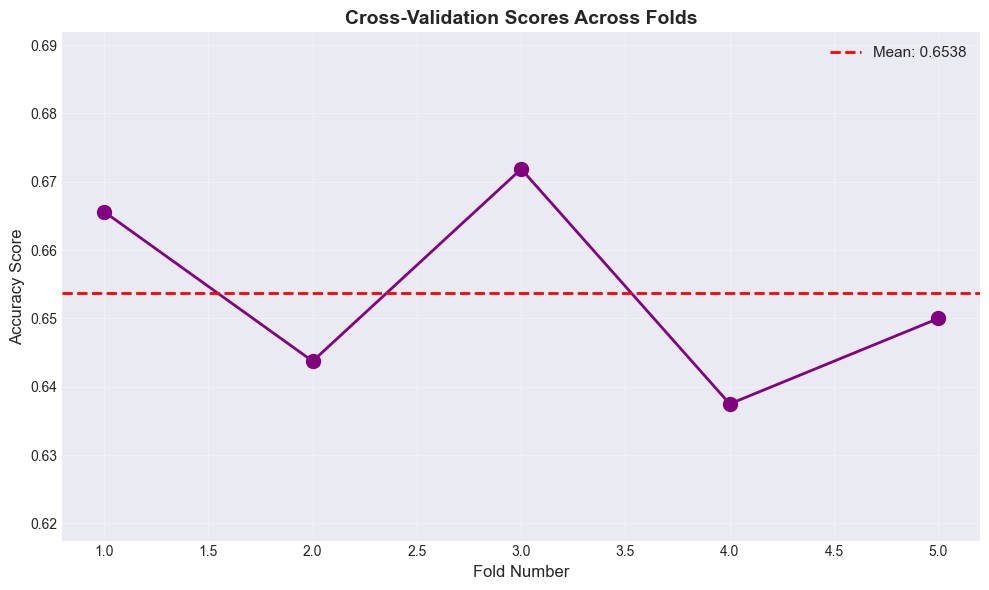

In [29]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Results (5-Fold):")
print(f"Individual fold scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Min CV Accuracy: {cv_scores.min():.4f}")
print(f"Max CV Accuracy: {cv_scores.max():.4f}")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linewidth=2, markersize=10, color='purple')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}', linewidth=2)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Cross-Validation Scores Across Folds', fontsize=14, fontweight='bold')
plt.ylim([cv_scores.min() - 0.02, cv_scores.max() + 0.02])
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning with GridSearchCV

In [30]:
# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'saga'],  # Optimization algorithm
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [31]:
# Fit grid search
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [32]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-Score: 0.6504


In [33]:
# Get the best model
best_log_reg = grid_search.best_estimator_

# Make predictions with the best model
y_train_pred_best = best_log_reg.predict(X_train_scaled)
y_test_pred_best = best_log_reg.predict(X_test_scaled)
y_train_pred_proba_best = best_log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_best = best_log_reg.predict_proba(X_test_scaled)[:, 1]

In [34]:
# Evaluate the best model
train_metrics_best = evaluate_model(y_train, y_train_pred_best, y_train_pred_proba_best, 'Training Set (Best Model)')
test_metrics_best = evaluate_model(y_test, y_test_pred_best, y_test_pred_proba_best, 'Testing Set (Best Model)')

Evaluation Metrics for Training Set (Best Model)

Accuracy:  0.6631 (66.31%)
Precision: 0.6528 (65.28%)
Recall:    0.6637 (66.37%)
F1-Score:  0.6582 (65.82%)
ROC-AUC:   0.7288 (72.88%)
Evaluation Metrics for Testing Set (Best Model)

Accuracy:  0.6500 (65.00%)
Precision: 0.6359 (63.59%)
Recall:    0.6684 (66.84%)
F1-Score:  0.6517 (65.17%)
ROC-AUC:   0.6839 (68.39%)


In [35]:
# Compare baseline vs tuned model
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Model': [test_metrics['accuracy'], test_metrics['precision'], 
                       test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']],
    'Tuned Model': [test_metrics_best['accuracy'], test_metrics_best['precision'],
                   test_metrics_best['recall'], test_metrics_best['f1'], test_metrics_best['roc_auc']]
})

comparison_df['Improvement'] = ((comparison_df['Tuned Model'] - comparison_df['Baseline Model']) / 
                                comparison_df['Baseline Model'] * 100)

print("\nModel Comparison - Baseline vs Tuned:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


Model Comparison - Baseline vs Tuned:
   Metric  Baseline Model  Tuned Model  Improvement
 Accuracy        0.640000     0.650000     1.562500
Precision        0.630000     0.635922     0.940052
   Recall        0.642857     0.668367     3.968254
 F1-Score        0.636364     0.651741     2.416489
  ROC-AUC        0.683498     0.683949     0.065864


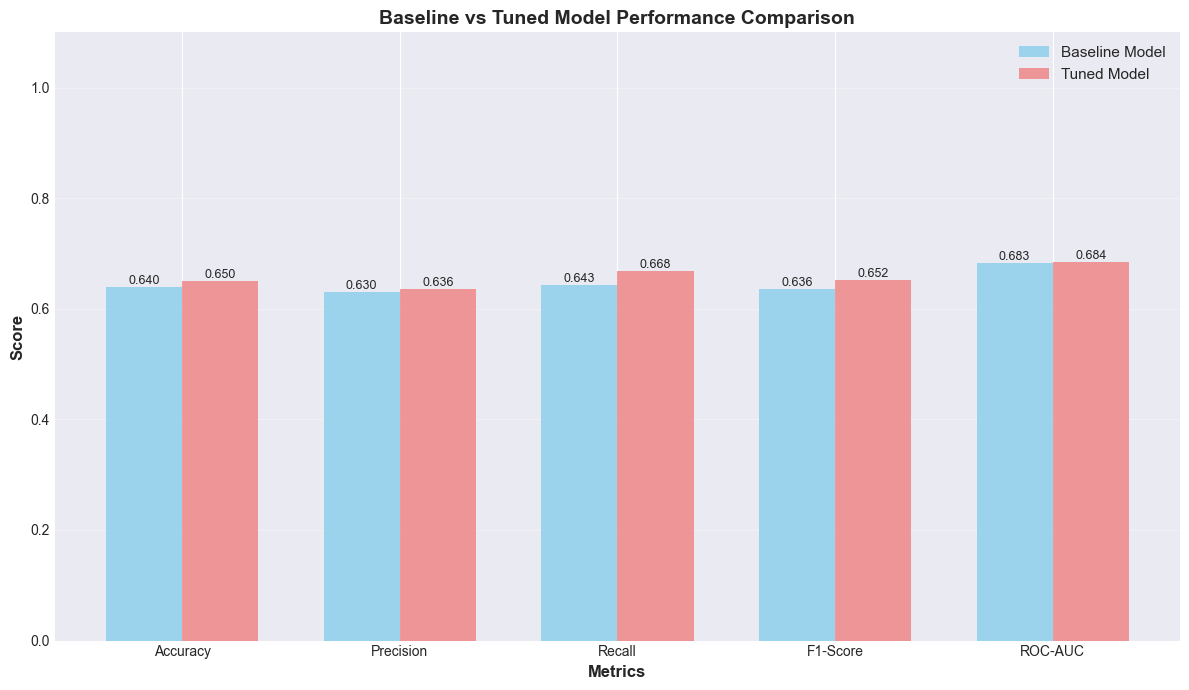

In [36]:
# Visualize model comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_values = comparison_df['Baseline Model'].values
tuned_values = comparison_df['Tuned Model'].values

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline Model', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, tuned_values, width, label='Tuned Model', color='lightcoral', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs Tuned Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis

In [37]:
# Get feature coefficients from the best model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_log_reg.coef_[0]
})

# Sort by absolute coefficient value
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (based on coefficients):")
print("="*80)
print(feature_importance.to_string(index=False))
print("="*80)

Feature Importance (based on coefficients):
                       Feature  Coefficient  Abs_Coefficient
         ContractType_One year    -0.559425         0.559425
         ContractType_Two year    -0.495083         0.495083
                MonthlyCharges     0.444553         0.444553
               TechSupport_Yes    -0.290064         0.290064
PaymentMethod_Electronic check     0.284962         0.284962
                        Tenure    -0.168769         0.168769
            OnlineSecurity_Yes    -0.130921         0.130921
   InternetService_Fiber optic     0.129078         0.129078
                  TotalCharges    -0.107601         0.107601
            InternetService_No     0.059456         0.059456
                   DataUsageGB     0.044350         0.044350
                           Age    -0.039322         0.039322
    PaymentMethod_Mailed check    -0.037087         0.037087
          CustomerServiceCalls     0.035326         0.035326
     PaymentMethod_Credit card    -0.0269

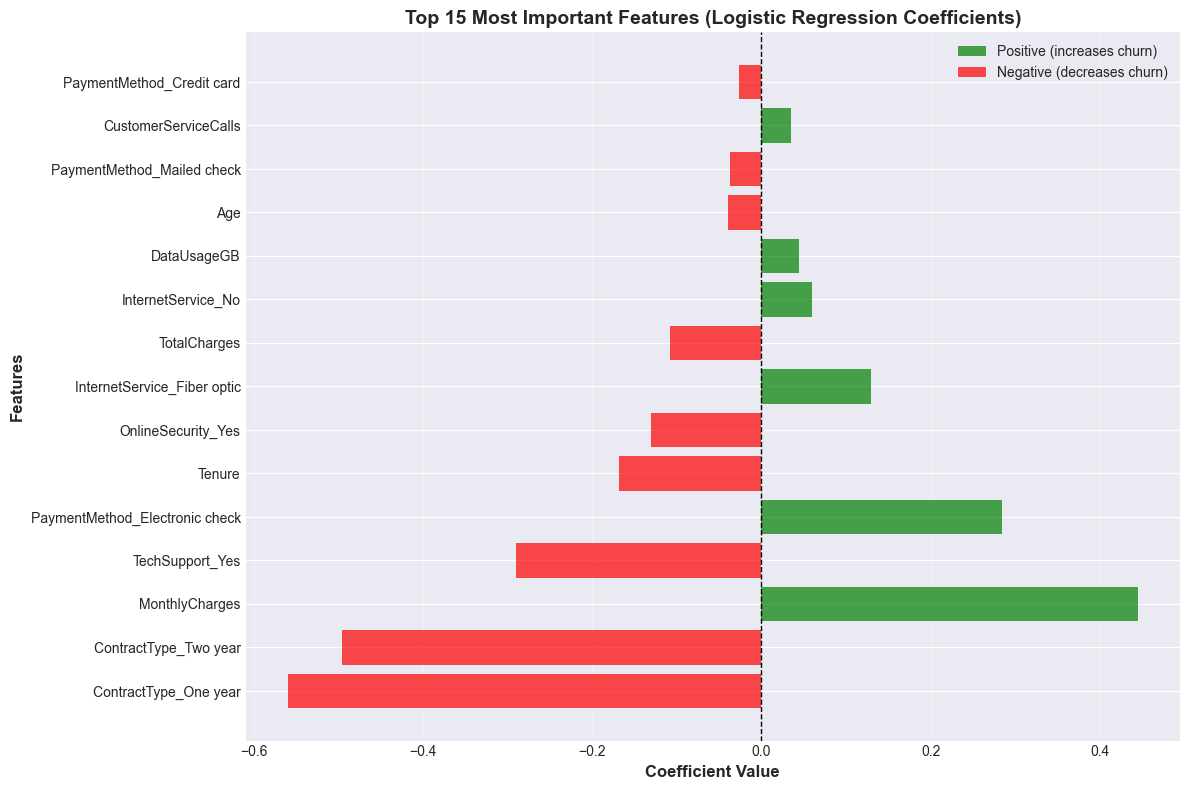

In [38]:
# Visualize top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features (Logistic Regression Coefficients)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Positive (increases churn)'),
                   Patch(facecolor='red', alpha=0.7, label='Negative (decreases churn)')]
plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Model Comparison with Other Algorithms

In [39]:
# Train additional models for comparison
models = {
    'Logistic Regression': best_log_reg,
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
}

model_results = {}

for model_name, model in models.items():
    if model_name != 'Logistic Regression':
        print(f"Training {model_name}...")
        model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    model_results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Create comparison dataframe
comparison_models_df = pd.DataFrame(model_results).T

print("\nModel Comparison Results:")
print("="*80)
print(comparison_models_df)
print("="*80)

Training Decision Tree...
Training Random Forest...

Model Comparison Results:
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression    0.6500   0.635922  0.668367  0.651741  0.683949
Decision Tree          0.5700   0.554545  0.622449  0.586538  0.578594
Random Forest          0.6025   0.598930  0.571429  0.584856  0.640681


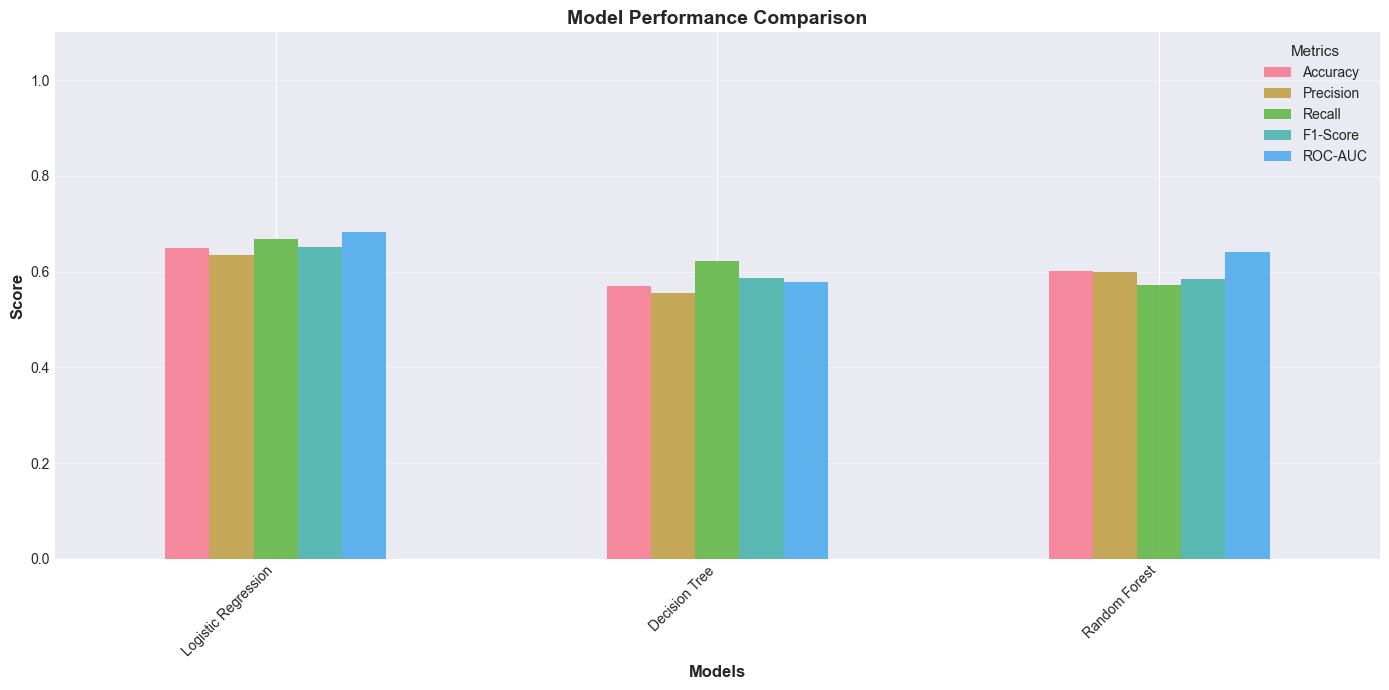

In [40]:
# Visualize model comparison
comparison_models_df.plot(kind='bar', figsize=(14, 7), alpha=0.8)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1.1])
plt.legend(title='Metrics', fontsize=10, title_fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Prediction Examples

In [41]:
# Make predictions on sample data
sample_indices = np.random.choice(X_test.index, 5, replace=False)
sample_data = X_test.loc[sample_indices]
sample_actual = y_test.loc[sample_indices]

# Scale sample data
sample_scaled = scaler.transform(sample_data)

# Predictions
sample_predictions = best_log_reg.predict(sample_scaled)
sample_probabilities = best_log_reg.predict_proba(sample_scaled)[:, 1]

# Display results
print("Sample Predictions:")
print("="*100)
for i, idx in enumerate(sample_indices):
    print(f"\nCustomer {i+1}:")
    print(f"  Actual Churn: {'Yes' if sample_actual.iloc[i] == 1 else 'No'}")
    print(f"  Predicted Churn: {'Yes' if sample_predictions[i] == 1 else 'No'}")
    print(f"  Churn Probability: {sample_probabilities[i]:.2%}")
    print(f"  Correct: {'Yes' if sample_predictions[i] == sample_actual.iloc[i] else 'No'}")
print("="*100)

Sample Predictions:

Customer 1:
  Actual Churn: No
  Predicted Churn: No
  Churn Probability: 35.30%
  Correct: Yes

Customer 2:
  Actual Churn: No
  Predicted Churn: No
  Churn Probability: 33.28%
  Correct: Yes

Customer 3:
  Actual Churn: No
  Predicted Churn: No
  Churn Probability: 31.84%
  Correct: Yes

Customer 4:
  Actual Churn: Yes
  Predicted Churn: Yes
  Churn Probability: 76.72%
  Correct: Yes

Customer 5:
  Actual Churn: Yes
  Predicted Churn: Yes
  Churn Probability: 67.23%
  Correct: Yes


## 12. Key Insights and Conclusions

In [42]:
print("="*80)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("="*80)

print("\n1. MODEL PERFORMANCE:")
print(f"   - Best Model: Logistic Regression with hyperparameter tuning")
print(f"   - Test Accuracy: {test_metrics_best['accuracy']:.2%}")
print(f"   - Test F1-Score: {test_metrics_best['f1']:.2%}")
print(f"   - Test ROC-AUC: {test_metrics_best['roc_auc']:.2%}")

print("\n2. MOST IMPORTANT FEATURES FOR CHURN PREDICTION:")
for i, row in feature_importance.head(5).iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   - {row['Feature']}: {direction} churn likelihood (coef: {row['Coefficient']:.4f})")

print("\n3. MODEL COMPARISON:")
best_model = comparison_models_df['F1-Score'].idxmax()
print(f"   - Best performing model: {best_model}")
print(f"   - F1-Score: {comparison_models_df.loc[best_model, 'F1-Score']:.2%}")

print("\n4. CROSS-VALIDATION:")
print(f"   - Mean CV Score: {cv_scores.mean():.2%} (±{cv_scores.std()*2:.2%})")
print(f"   - Model shows consistent performance across folds")

KEY INSIGHTS FROM THE ANALYSIS

1. MODEL PERFORMANCE:
   - Best Model: Logistic Regression with hyperparameter tuning
   - Test Accuracy: 65.00%
   - Test F1-Score: 65.17%
   - Test ROC-AUC: 68.39%

2. MOST IMPORTANT FEATURES FOR CHURN PREDICTION:
   - ContractType_One year: decreases churn likelihood (coef: -0.5594)
   - ContractType_Two year: decreases churn likelihood (coef: -0.4951)
   - MonthlyCharges: increases churn likelihood (coef: 0.4446)
   - TechSupport_Yes: decreases churn likelihood (coef: -0.2901)
   - PaymentMethod_Electronic check: increases churn likelihood (coef: 0.2850)

3. MODEL COMPARISON:
   - Best performing model: Logistic Regression
   - F1-Score: 65.17%

4. CROSS-VALIDATION:
   - Mean CV Score: 65.38% (±2.60%)
   - Model shows consistent performance across folds


In [44]:
import joblib

# Load model
model = joblib.load("model.joblib")